#### Get dataset from Kaggle

In [ ]:
# uncomment to download
!curl -L -o e-commerce-fraud-detection-dataset.zip https://www.kaggle.com/api/v1/datasets/download/umuttuygurr/e-commerce-fraud-detection-dataset
!unzip e-commerce-fraud-detection-dataset.zip -d data
!rm e-commerce-fraud-detection-dataset.zip

#### Helper functions

In [1]:
def load_csv_data(csv_data_file, verbose=True):
    df = pd.read_csv(csv_data_file,
                     low_memory=False
    )
    if verbose:
        print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
        print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    return df

def plot_target_distribution(df, target_col):
    # Visualize target variable distribution
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    
    # Count plot
    df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
    axes[0].set_title(f'Target Variable ({target_col}) Distribution', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].set_xticklabels(['Regular (0)', 'Fraud (1)'], rotation=0)
    
    # Percentage plot
    df[target_col].value_counts(normalize=True).plot(kind='bar', ax=axes[1], color=['skyblue', 'salmon'])
    axes[1].set_title(f'Target Variable ({target_col}) Distribution in %', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Percentage')
    axes[1].set_xticklabels(['Regular (0)', 'Fraud (1)'], rotation=0)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    
    plt.tight_layout()
    plt.show()

def plot_box_plots(df, numeric_features, target_col):
    """Compare feature distributions between fraud and normal transactions using box plots."""
    fig, axes = plt.subplots(3, 2, figsize=(15, 13))
    axes = axes.flatten()
    
    for idx, col in enumerate(numeric_features):
        ax = axes[idx]
        df.boxplot(column=col, by=target_col, ax=ax, patch_artist=True)
        ax.set_title(f'{col} by Fraud Status', fontsize=11, fontweight='bold')
        ax.set_xlabel('Is Fraud')
        ax.set_ylabel(col)
        ax.set_xticklabels(['Normal', 'Fraud'])
        plt.sca(ax)
        plt.xticks([1, 2], ['Normal (0)', 'Fraud (1)'])
    
    if len(numeric_features) < len(axes):
        fig.delaxes(axes[-1])
    
    plt.suptitle('')
    plt.tight_layout()
    plt.show()
    
    print("\nBox Plot Interpretation:")
    print("* Look for differences in medians (center line) between fraud and normal")
    print("* Different distributions suggest the feature is discriminative")
    print("* Overlapping boxes indicate less predictive power")

def analyze_categorical_features(df, categorical_features, target_col):
    """Analyze fraud rates for each categorical feature."""
    print("Fraud Rates by Categorical Features")
    print("=" * 80)
    
    for feature in categorical_features:
        print(f"\n{feature.upper()}:")
        print("-" * 80)
        
        fraud_rate = df.groupby(feature)[target_col].agg(['sum', 'count', 'mean']).reset_index()
        fraud_rate.columns = [feature, 'fraud_count', 'total_count', 'fraud_rate']
        fraud_rate['fraud_rate'] = fraud_rate['fraud_rate'] * 100
        fraud_rate = fraud_rate.sort_values('fraud_rate', ascending=False)
        
        print(fraud_rate.to_string(index=False))
        
        baseline_rate = df[target_col].mean() * 100
        high_risk = fraud_rate[fraud_rate['fraud_rate'] > baseline_rate * 1.5]
        if not high_risk.empty:
            print(f"\n⚠️  High-risk categories (>1.5x baseline rate of {baseline_rate:.2f}%):")
            for _, row in high_risk.iterrows():
                print(f"   - {row[feature]}: {row['fraud_rate']:.2f}% fraud rate")
    
    print("\n" + "=" * 80)

def download_data_csv(kaggle_source, data_dir, csv_file):
    """Download csv file from kaggle_source. Requires install of kaggle python
    package to use the Kaggle API and Kaggle API credentials set up in
    `~/.kaggle/kaggle.json`. Creates data directory, data_dir, if it doesn't
    exist. csv_file is the name of the downloaded file.
    """
    Path(data_dir).mkdir(parents=True, exist_ok=True)
    if not os.path.exists(f"{data_dir}/{csv_file}"):
        print(f"\nDownloading dataset from Kaggle...")
        !kaggle datasets download -d {kaggle_source} -p {data_dir} --unzip
        print("Download complete!")
    else:
        print(f"\nDataset already exists at {data_dir}/{csv_file}")

def load_data(data_dir, csv_file, verbose=True):
    df = pd.read_csv(
        f"{data_dir}/{csv_file}",
        low_memory=False  # Read entire file to infer dtypes properly
    )
    if verbose:
        print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
        print(f"\nMemory Usage:\n{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    return df
    
def plot_target_distribution(df, target_col):
    # Visualize target variable distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Count plot
    df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
    axes[0].set_title('Target Variable Distribution (Count)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Is Fraud')
    axes[0].set_ylabel('Count')
    axes[0].set_xticklabels(['Normal (0)', 'Fraud (1)'], rotation=0)
    
    # Percentage plot
    df[target_col].value_counts(normalize=True).plot(kind='bar', ax=axes[1], color=['skyblue', 'salmon'])
    axes[1].set_title('Target Variable Distribution (Percentage)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Is Fraud')
    axes[1].set_ylabel('Percentage')
    axes[1].set_xticklabels(['Normal (0)', 'Fraud (1)'], rotation=0)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    
    plt.tight_layout()
    plt.show()
    
def analyze_target_stats(df, target_col):
    # Target distribution
    target_dist = df[target_col].value_counts(normalize=True)
    print("\nTarget Distribution (%):")
    print(target_dist * 100)
    # Check class imbalance
    target_vals = target_dist.values
    target_ratio = target_vals[0] / target_vals[1]
    if target_ratio > 10:
        print(f"\n{BOLD}Warning: Large class imbalance ({target_ratio:.1f}) detected!\n")
    else:
        print(f"\nClass imbalance = {target_ratio:.1f}\n")
    plot_target_distribution(df, target_col)

def analyze_feature_stats(df, id_cols, target_col, categorical_features, numeric_features):
    # Summary for categorical/object columns
    print(f"\nCategorical Features ({len(categorical_features)}): {categorical_features}")
    if len(categorical_features) > 0:
        print("\nCategorical Features Summary:")
        for col in categorical_features:
            print(f"\n{col}:")
            print(f"  Unique values: {df[col].nunique()}")
            print(f"  Top 5 values:\n{df[col].value_counts().head()}")

    # Statistical summary for numerical columns
    print(f"\n\nNumeric Features ({len(numeric_features)}): {numeric_features}")
    print("\nNumeric Features Summary:")
    display(df[numeric_features].describe())
        
def split_train_val_test(df, val_ratio=.2, test_ratio=.2, stratify=None, r_seed=1, verbose=False):
    """Use the train_test_split function from sklearn to split input dataframe
    into randomly shuffled train, validation, and test datasets. Stratify, if provided, gives 
    the column name to use when stratifying the splits.
    """
    n = len(df)
    # Generate test dataset
    strat_col = stratify
    if stratify:
        strat_col = df[stratify]
    full_train_df, test_df = train_test_split(df, test_size=test_ratio, stratify=strat_col, random_state=r_seed)
    test_df = test_df.reset_index(drop=True)
    # Generate train, validation, and test splits
    val_ft_ratio = val_ratio / (1 - test_ratio)
    if stratify:
        strat_col = full_train_df[stratify]
    train_df, val_df = train_test_split(full_train_df, test_size=val_ft_ratio, stratify=strat_col, random_state=r_seed)
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    if verbose:
        print(f"All rows in the original dataframe are contained within the training, validation, or test datasets: {len(train_df) + len(val_df) + len(test_df) == len(df)}")
        print(f"\nTrain set: {len(train_df)} rows ({len(train_df)/len(df)*100:.1f}%)")
        print(f"Validation set: {len(val_df)} rows ({len(val_df)/len(df)*100:.1f}%)")
        print(f"Test set: {len(test_df)} rows ({len(test_df)/len(df)*100:.1f}%)")
    return train_df, val_df, test_df

#### Feature engineering

In [2]:
def get_country_timezone_mapping():
    """Create mapping of country codes to capital city timezones."""
    return {
        'US': 'America/New_York',       # Washington D.C.
        'GB': 'Europe/London',          # London
        'FR': 'Europe/Paris',           # Paris
        'DE': 'Europe/Berlin',          # Berlin
        'IT': 'Europe/Rome',            # Rome
        'ES': 'Europe/Madrid',          # Madrid
        'NL': 'Europe/Amsterdam',       # Amsterdam
        'PL': 'Europe/Warsaw',          # Warsaw
        'RO': 'Europe/Bucharest',       # Bucharest
        'TR': 'Europe/Istanbul'         # Istanbul
    }

def convert_utc_to_local_time(df, date_col, country_col):
    """
    Convert UTC timestamps to local time based on country's capital timezone.
    Returns DataFrame with additional local_time column.

    Requires:
        - date_col must be timezone-aware datetime in UTC
        - Will raise ValueError if timezone is missing or not UTC
    """
    df = df.copy()
    tz_mapping = get_country_timezone_mapping()
    
    # Initialize local_time column (timezone-naive, will represent local times)
    df['local_time'] = df[date_col].dt.tz_localize(None)
    
    print("Converting UTC to local time by country...")
    for country, tz_str in tz_mapping.items():
        mask = df[country_col] == country
        if mask.sum() > 0:
            # Convert UTC to local timezone
            # Get the datetime series
            dt_series = df.loc[mask, date_col]

            # Validate that input is timezone-aware and in UTC
            if dt_series.dt.tz is None:
                raise ValueError(
                    f"Column '{date_col}' must be timezone-aware in UTC. "
                    f"Ensure timestamps are parsed with utc=True during data loading."
                )

            # Validate it's in UTC
            if str(dt_series.dt.tz) != 'UTC':
                raise ValueError(
                    f"Column '{date_col}' must be in UTC timezone, "
                    f"but found: {dt_series.dt.tz}"
                )

            # Convert UTC to target local timezone
            utc_times = dt_series
            local_times = utc_times.dt.tz_convert(tz_str).dt.tz_localize(None)
            df.loc[mask, 'local_time'] = local_times
    
    print(f"  ✓ Converted {len(df)} transactions to local time")
    return df

def create_temporal_features(df, date_col, use_local_time=False):
    """
    Create time features from timestamp column.
    """
    df = df.copy()
    time_col = 'local_time' if use_local_time else date_col
    suffix = '_local' if use_local_time else ''
    
    # Extract basic time components
    df[f'hour{suffix}'] = df[time_col].dt.hour
    df[f'day_of_week{suffix}'] = df[time_col].dt.dayofweek  # 0=Monday, 6=Sunday
    df[f'month{suffix}'] = df[time_col].dt.month
    
    # Derived temporal features
    df[f'is_weekend{suffix}'] = (df[f'day_of_week{suffix}'] >= 5).astype(int)
    df[f'is_late_night{suffix}'] = ((df[f'hour{suffix}'] >= 23) | (df[f'hour{suffix}'] <= 4)).astype(int)
    df[f'is_business_hours{suffix}'] = ((df[f'hour{suffix}'] >= 9) & (df[f'hour{suffix}'] <= 17)).astype(int)
    
    features_created = [f'hour{suffix}', f'day_of_week{suffix}', f'month{suffix}',
                       f'is_weekend{suffix}', f'is_late_night{suffix}', f'is_business_hours{suffix}']
    
    return df, features_created

def create_extra_features(df):
    df = df.copy()
    
    # Amount deviation from user's average
    df['amount_deviation'] = (df['amount'] - df['avg_amount_user']).abs()
    
    # Amount ratio compared to user's average (handle division by zero)
    df['amount_vs_avg_ratio'] = df['amount'] / df['avg_amount_user'].replace(0, 1)
    
    # Micro transactions (potential card testing)
    df['is_micro_transaction'] = (df['amount'] <= 5).astype(int)
    
    # Large transactions
    df['is_large_transaction'] = (df['amount'] >= df['amount'].quantile(0.95)).astype(int)

    df['is_new_account'] = (df['account_age_days'] <= 30).astype(int)
    
    # High frequency user
    df['is_high_frequency_user'] = (df['total_transactions_user'] >= df['total_transactions_user'].quantile(0.75)).astype(int)

    # Country mismatch (user country != card issuing country)
    df['country_mismatch'] = (df['country'] != df['bin_country']).astype(int)
    
    # High risk shipping distance (>80th percentile)
    distance_threshold = df['shipping_distance_km'].quantile(0.8)

    df['high_risk_distance'] = (df['shipping_distance_km'] > distance_threshold).astype(int)

    # Security score (count of passed verifications)
    df['security_score'] = df['avs_match'] + df['cvv_result'] + df['three_ds_flag']
    
    # Count of failed verifications
    df['verification_failures'] = 3 - df['security_score']
    
    # All verifications passed
    df['all_verifications_passed'] = (df['security_score'] == 3).astype(int)
    
    # All verifications failed (high risk)
    df['all_verifications_failed'] = (df['security_score'] == 0).astype(int)
    features = ['amount_deviation', 'amount_vs_avg_ratio', 'is_micro_transaction', 'is_large_transaction', 
                'is_new_account', 'is_high_frequency_user', 'country_mismatch', 'high_risk_distance', 
                'security_score', 'verification_failures', 'all_verifications_passed', 'all_verifications_failed']

    return df, features

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)


In [4]:
df = load_csv_data('data/transactions.csv')


Dataset Shape: 299695 rows, 17 columns
Memory Usage: 107.29 MB


In [5]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,299685,299686,299687,299688,299689,299690,299691,299692,299693,299694
transaction_id,1,2,3,4,5,6,7,8,9,10,...,299686,299687,299688,299689,299690,299691,299692,299693,299694,299695
user_id,1,1,1,1,1,1,1,1,1,1,...,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000
account_age_days,141,141,141,141,141,141,141,141,141,141,...,996,996,996,996,996,996,996,996,996,996
total_transactions_user,47,47,47,47,47,47,47,47,47,47,...,45,45,45,45,45,45,45,45,45,45
avg_amount_user,147.93,147.93,147.93,147.93,147.93,147.93,147.93,147.93,147.93,147.93,...,27.93,27.93,27.93,27.93,27.93,27.93,27.93,27.93,27.93,27.93
amount,84.75,107.9,92.36,112.47,132.91,224.82,125.98,66.95,261.58,97.34,...,14.77,22.82,33.97,22.42,100.16,34.07,68.56,25.02,23.92,26.07
country,FR,FR,FR,FR,FR,FR,FR,FR,FR,FR,...,ES,ES,ES,ES,ES,ES,ES,ES,ES,ES
bin_country,FR,FR,FR,FR,US,FR,FR,RO,FR,FR,...,ES,ES,ES,ES,ES,ES,ES,ES,ES,ES
channel,web,web,app,web,web,web,app,web,app,web,...,web,web,app,web,app,web,app,app,web,web
merchant_category,travel,travel,travel,fashion,electronics,travel,electronics,travel,grocery,electronics,...,gaming,fashion,electronics,electronics,travel,grocery,travel,fashion,gaming,gaming


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           299695 non-null  int64  
 1   user_id                  299695 non-null  int64  
 2   account_age_days         299695 non-null  int64  
 3   total_transactions_user  299695 non-null  int64  
 4   avg_amount_user          299695 non-null  float64
 5   amount                   299695 non-null  float64
 6   country                  299695 non-null  object 
 7   bin_country              299695 non-null  object 
 8   channel                  299695 non-null  object 
 9   merchant_category        299695 non-null  object 
 10  promo_used               299695 non-null  int64  
 11  avs_match                299695 non-null  int64  
 12  cvv_result               299695 non-null  int64  
 13  three_ds_flag            299695 non-null  int64  
 14  tran

#### Define feature types

In [7]:
target_col = "is_fraud"
id_cols = ['transaction_id', 'user_id']
datetime_col = 'transaction_time'
# categorical
categorical_feats = ['country', 'bin_country', 'channel', 'merchant_category', 
                       'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag']
# numeric
numeric_feats = ['account_age_days', 'total_transactions_user', 'avg_amount_user', 
                   'amount', 'shipping_distance_km']

In [8]:
# convert to datetime
df[datetime_col] = pd.to_datetime(df[datetime_col], utc=True, errors='coerce')

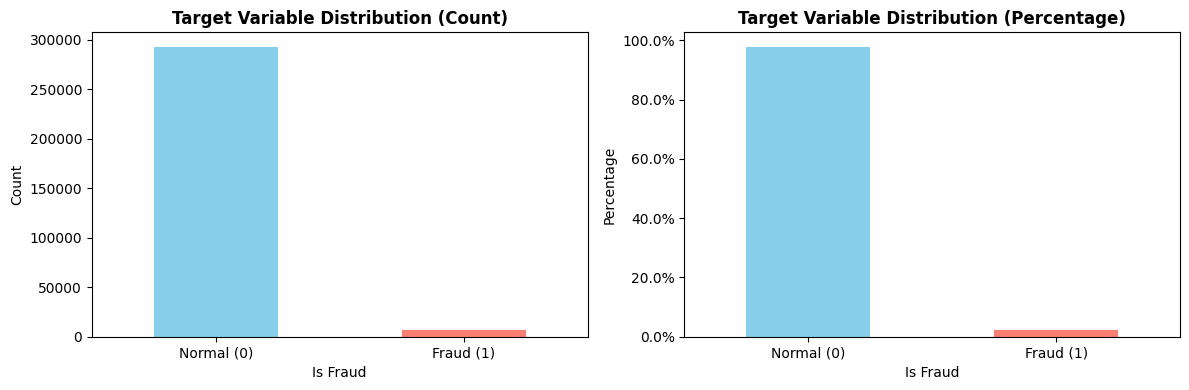

In [9]:
plot_target_distribution(df, target_col)

In [10]:
target_dist = df[target_col].value_counts()
print(f'Target class imbalance (#regular/#fraud): {target_dist[0]/target_dist[1]}')

Target class imbalance (#regular/#fraud): 44.325922565033274


#### Numeric features

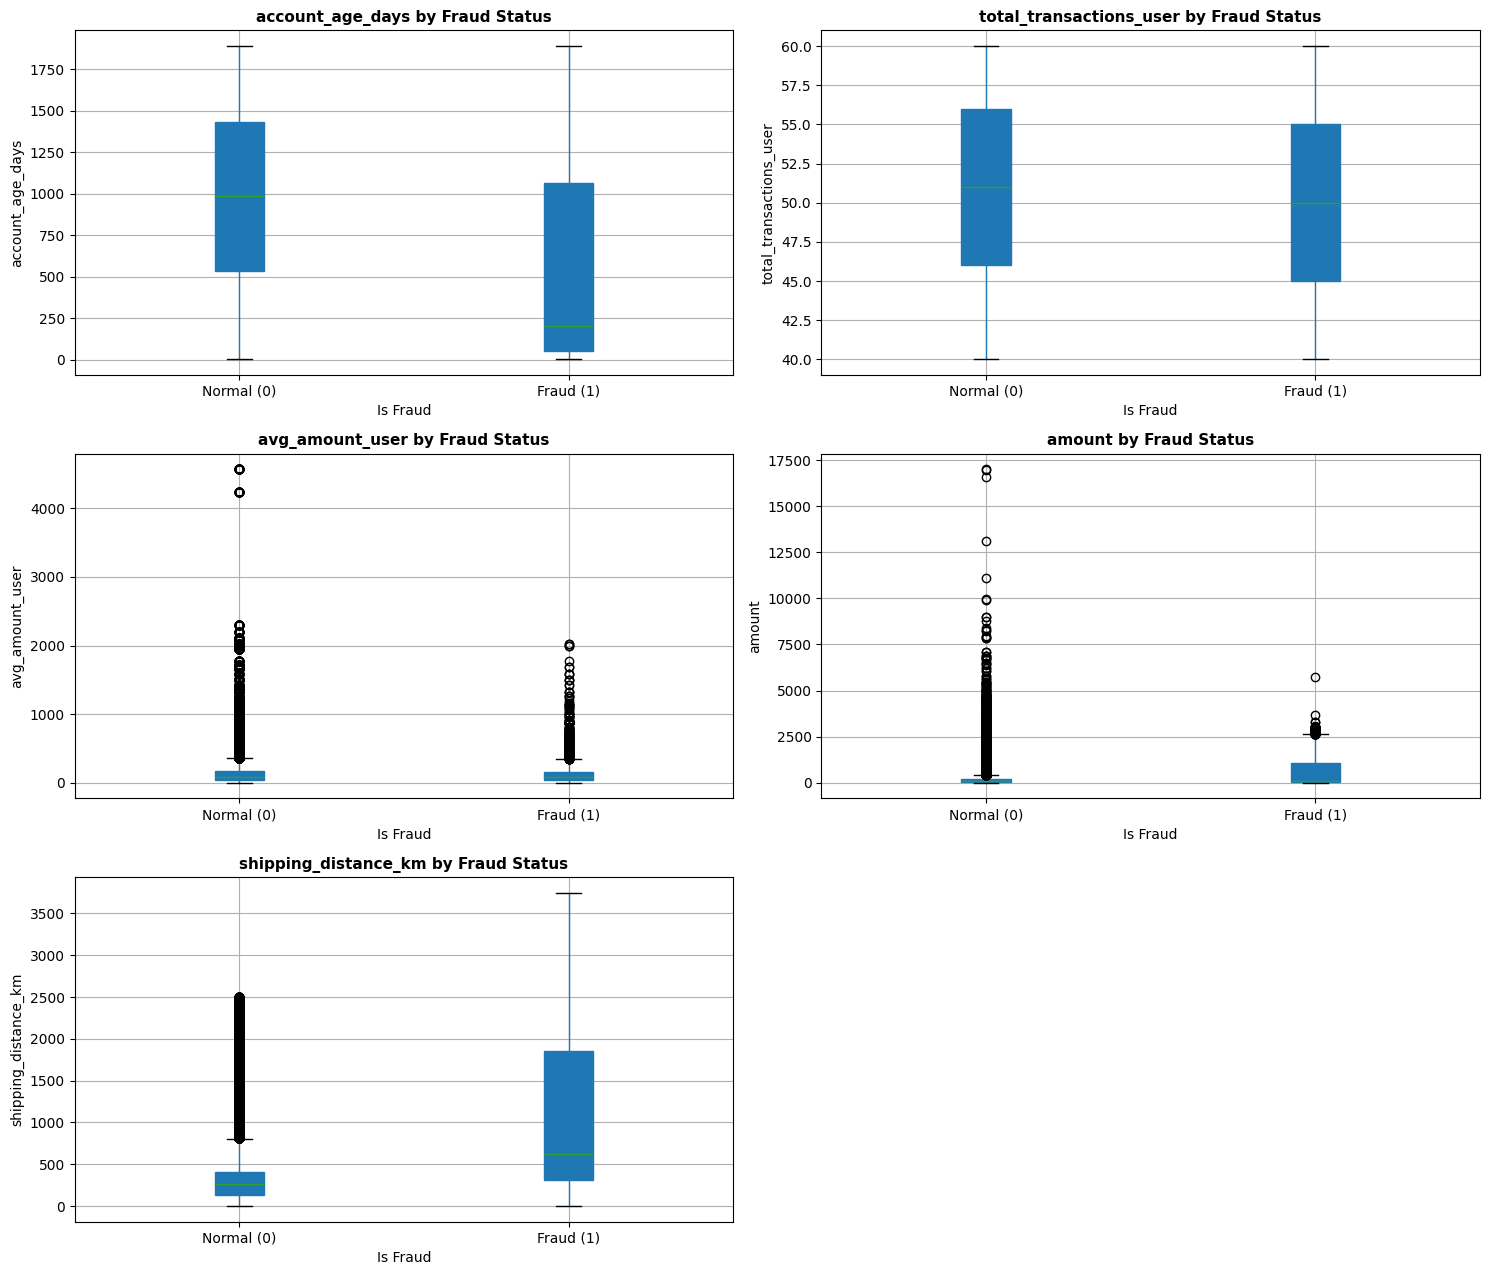


Box Plot Interpretation:
* Look for differences in medians (center line) between fraud and normal
* Different distributions suggest the feature is discriminative
* Overlapping boxes indicate less predictive power


In [11]:
plot_box_plots(df, numeric_feats, target_col)

#### Categorical features

In [12]:
analyze_categorical_features(df, categorical_feats, target_col)

Fraud Rates by Categorical Features

COUNTRY:
--------------------------------------------------------------------------------
country  fraud_count  total_count  fraud_rate
     TR          843        30074    2.803086
     RO          709        29501    2.403308
     PL          701        29965    2.339396
     ES          668        28885    2.312619
     US          748        32430    2.306506
     FR          664        30343    2.188314
     IT          607        28615    2.121265
     GB          648        30602    2.117509
     NL          539        30220    1.783587
     DE          485        29060    1.668961

BIN_COUNTRY:
--------------------------------------------------------------------------------
bin_country  fraud_count  total_count  fraud_rate
         TR          781        29972    2.605765
         PL          699        29963    2.332877
         RO          679        29532    2.299201
         ES          666        29058    2.291968
         IT          6

#### Create features based on transaction times

In [13]:
df_time = convert_utc_to_local_time(df, datetime_col, 'country')

df_time, local_features = create_temporal_features(df_time, datetime_col, use_local_time=True)
print(f" ✓ Created {len(local_features)} local time features")
print(local_features)

Converting UTC to local time by country...
  ✓ Converted 299695 transactions to local time
 ✓ Created 6 local time features
['hour_local', 'day_of_week_local', 'month_local', 'is_weekend_local', 'is_late_night_local', 'is_business_hours_local']


#### Create extra features based on base features 

In [14]:
df_eng, extra_features = create_extra_features(df_time)
print(f" ✓ Created {len(extra_features)} extra features: {extra_features}")

 ✓ Created 12 extra features: ['amount_deviation', 'amount_vs_avg_ratio', 'is_micro_transaction', 'is_large_transaction', 'is_new_account', 'is_high_frequency_user', 'country_mismatch', 'high_risk_distance', 'security_score', 'verification_failures', 'all_verifications_passed', 'all_verifications_failed']


In [15]:
df_eng.T

,0,1,2,3,4,5,6,7,8,9,...,299685,299686,299687,299688,299689,299690,299691,299692,299693,299694
transaction_id,1,2,3,4,5,6,7,8,9,10,...,299686,299687,299688,299689,299690,299691,299692,299693,299694,299695
user_id,1,1,1,1,1,1,1,1,1,1,...,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000
account_age_days,141,141,141,141,141,141,141,141,141,141,...,996,996,996,996,996,996,996,996,996,996
total_transactions_user,47,47,47,47,47,47,47,47,47,47,...,45,45,45,45,45,45,45,45,45,45
avg_amount_user,147.93,147.93,147.93,147.93,147.93,147.93,147.93,147.93,147.93,147.93,...,27.93,27.93,27.93,27.93,27.93,27.93,27.93,27.93,27.93,27.93
amount,84.75,107.9,92.36,112.47,132.91,224.82,125.98,66.95,261.58,97.34,...,14.77,22.82,33.97,22.42,100.16,34.07,68.56,25.02,23.92,26.07
country,FR,FR,FR,FR,FR,FR,FR,FR,FR,FR,...,ES,ES,ES,ES,ES,ES,ES,ES,ES,ES
bin_country,FR,FR,FR,FR,US,FR,FR,RO,FR,FR,...,ES,ES,ES,ES,ES,ES,ES,ES,ES,ES
channel,web,web,app,web,web,web,app,web,app,web,...,web,web,app,web,app,web,app,app,web,web
merchant_category,travel,travel,travel,fashion,electronics,travel,electronics,travel,grocery,electronics,...,gaming,fashion,electronics,electronics,travel,grocery,travel,fashion,gaming,gaming


#### Feature exclusion

In [16]:
exclude_cols = id_cols + ['country', 'bin_country', 'merchant_category', 'transaction_time', 'local_time', 
                          'verification_failures', 'all_verifications_passed', 'all_verifications_failed']

#### Train, validation and test datasets

In [17]:
train_df, val_df, test_df = split_train_val_test(df_eng.drop(exclude_cols, axis=1), val_ratio=0.2, test_ratio=0.2, stratify=target_col, verbose=True)

All rows in the original dataframe are contained within the training, validation, or test datasets: True

Train set: 179817 rows (60.0%)
Validation set: 59939 rows (20.0%)
Test set: 59939 rows (20.0%)


In [20]:
# Separate target from features
feature_cols = [col for col in train_df.columns if col != target_col]

# Identify numeric vs categorical features
numeric_features = train_df[feature_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = train_df[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()

# For binary features that might be stored as int, we may want to treat them as categorical
# Check for binary features in numeric columns
binary_features = []
for col in numeric_features:
    unique_vals = train_df[col].nunique()
    if unique_vals == 2:
        binary_features.append(col)

print(f"Feature breakdown:")
print(f"  • Total features: {len(feature_cols)}")
print(f"  • Numeric features: {len(numeric_features)}")
print(f"  • Categorical features: {len(categorical_features)}")
print(f"  • Binary features (int encoded): {len(binary_features)}")

print(f"\nNumeric features ({len(numeric_features)}):")
print(f"  {numeric_features}")

print(f"\nCategorical features ({len(categorical_features)}):")
print(f"  {categorical_features}")

if binary_features:
    print(f"\nBinary features ({len(binary_features)}):")
    print(f"  {binary_features}")

Feature breakdown:
  • Total features: 25
  • Numeric features: 21
  • Categorical features: 1
  • Binary features (int encoded): 13

Numeric features (21):
  ['account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'shipping_distance_km', 'is_weekend_local', 'is_late_night_local', 'is_business_hours_local', 'amount_deviation', 'amount_vs_avg_ratio', 'is_micro_transaction', 'is_large_transaction', 'is_new_account', 'is_high_frequency_user', 'country_mismatch', 'high_risk_distance', 'security_score']

Categorical features (1):
  ['channel']

Binary features (13):
  ['promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'is_weekend_local', 'is_late_night_local', 'is_business_hours_local', 'is_micro_transaction', 'is_large_transaction', 'is_new_account', 'is_high_frequency_user', 'country_mismatch', 'high_risk_distance']


In [24]:
# Continuous numeric (need scaling for Logistic Regression)
continuous_numeric = [
    'account_age_days', 'total_transactions_user', 'avg_amount_user', 
    'amount', 'shipping_distance_km', 'hour_local', 'day_of_week_local',
    'month_local', 'amount_deviation', 'amount_vs_avg_ratio', 'security_score'
]

# Categorical features (need encoding)
categorical = ['channel', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag']

# Binary features (no preprocessing)
binary = [
    'is_weekend_local', 'is_late_night_local', 'is_business_hours_local',
    'is_micro_transaction', 'is_large_transaction', 'is_new_account',
    'is_high_frequency_user', 'country_mismatch', 'high_risk_distance'
]

print("Feature categorization for preprocessing:")
print(f"  • Continuous numeric: {len(continuous_numeric)}")
print(f"  • Categorical: {len(categorical)}")
print(f"  • Binary: {len(binary)}")
print(f"  • Total: {len(continuous_numeric) + len(categorical) + len(binary)}")

all_features = continuous_numeric + categorical + binary
assert len(all_features) == 25, f"Expected 25 features, got {len(all_features)}"
print("\n✓ All 25 features categorized correctly")

Feature categorization for preprocessing:
  • Continuous numeric: 11
  • Categorical: 5
  • Binary: 9
  • Total: 25

✓ All 25 features categorized correctly


#### Preprocessing

In [26]:
# For Logistic Regression: Scale numeric + One-hot encode categorical
logistic_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), continuous_numeric),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical),
    ('binary', 'passthrough', binary)
], remainder='drop')

# For tree-based models: Simple ordinal encoding (optional, trees can handle categoricals)
# Using OrdinalEncoder for categorical features, passthrough for rest
tree_preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical),
    ('rest', 'passthrough', continuous_numeric + binary)
], remainder='drop')

print("✓ Preprocessing pipelines created:")
print("  • Logistic Regression: StandardScaler + OneHotEncoder")
print("  • Tree-based models: OrdinalEncoder (minimal)")

✓ Preprocessing pipelines created:
  • Logistic Regression: StandardScaler + OneHotEncoder
  • Tree-based models: OrdinalEncoder (minimal)


In [29]:
# evaluation function
def evaluate_model(model, X, y, model_name="Model", dataset_name="Validation"):
    """
    Evaluate classification model with fraud-appropriate metrics.
    
    Returns dict with all metrics.
    """
    # Get predictions
    y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    
    # Calculate metrics
    metrics = {
        'model': model_name,
        'dataset': dataset_name,
        'roc_auc': roc_auc_score(y, y_pred_proba),
        'pr_auc': average_precision_score(y, y_pred_proba),
        'f1': f1_score(y, y_pred),
        'precision': precision_score(y, y_pred),
        'recall': recall_score(y, y_pred),
        'accuracy': (y_pred == y).mean()
    }
    
    # Print results
    print(f"\n{model_name} - {dataset_name} Set Performance:")
    print("=" * 60)
    print(f"  ROC-AUC:    {metrics['roc_auc']:.4f}")
    print(f"  PR-AUC:     {metrics['pr_auc']:.4f}")
    print(f"  F1 Score:   {metrics['f1']:.4f}")
    print(f"  Precision:  {metrics['precision']:.4f}")
    print(f"  Recall:     {metrics['recall']:.4f}")
    print(f"  Accuracy:   {metrics['accuracy']:.4f}")
    print("=" * 60)
    
    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"  TN: {cm[0, 0]:,}  |  FP: {cm[0, 1]:,}")
    print(f"  FN: {cm[1, 0]:,}  |  TP: {cm[1, 1]:,}")
    
    return metrics

In [31]:
# Train Logistic Regression baseline
print("Training Logistic Regression...")

# Separate features and target
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_val = val_df.drop(columns=[target_col])
y_val = val_df[target_col]

# Create pipeline
logistic_pipeline = Pipeline([
    ('preprocessor', logistic_preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',  # Handle class imbalance
        max_iter=1000,
        random_state=1
    ))
])

# Train
logistic_pipeline.fit(X_train, y_train)

# Evaluate
logistic_metrics = evaluate_model(
    logistic_pipeline, 
    X_val, 
    y_val, 
    model_name="Logistic Regression",
    dataset_name="Validation"
)

print("\n✓ Logistic Regression baseline trained")

Training Logistic Regression...

Logistic Regression - Validation Set Performance:
  ROC-AUC:    0.9648
  PR-AUC:     0.7388
  F1 Score:   0.3244
  Precision:  0.1985
  Recall:     0.8874
  Accuracy:   0.9184

Confusion Matrix:
  TN: 53,876  |  FP: 4,740
  FN: 149  |  TP: 1,174

✓ Logistic Regression baseline trained


In [32]:
# Train Random Forest baseline
print("Training Random Forest...")

# Create pipeline
rf_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',  # Handle class imbalance
        random_state=1,
        n_jobs=-1  # Use all cores
    ))
])

# Train
rf_pipeline.fit(X_train, y_train)

# Evaluate
rf_metrics = evaluate_model(
    rf_pipeline, 
    X_val, 
    y_val, 
    model_name="Random Forest",
    dataset_name="Validation"
)

print("\n✓ Random Forest baseline trained")

Training Random Forest...

Random Forest - Validation Set Performance:
  ROC-AUC:    0.9623
  PR-AUC:     0.8527
  F1 Score:   0.8191
  Precision:  0.9492
  Recall:     0.7203
  Accuracy:   0.9930

Confusion Matrix:
  TN: 58,565  |  FP: 51
  FN: 370  |  TP: 953

✓ Random Forest baseline trained


In [37]:
# train xgboost baseline
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance ratio: {scale_pos_weight:.1f}:1")
print(f"Using scale_pos_weight={scale_pos_weight:.1f}")

# Create pipeline
xgb_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators=100,
        scale_pos_weight=scale_pos_weight,  # Handle class imbalance
        random_state=1,
        n_jobs=-1,  # Use all cores
        eval_metric='logloss'  # Suppress warning
    ))
])

# Train
xgb_pipeline.fit(X_train, y_train)

# Evaluate
xgb_metrics = evaluate_model(
    xgb_pipeline, 
    X_val, 
    y_val, 
    model_name="XGBoost",
    dataset_name="Validation"
)

print("\n✓ XGBoost baseline trained")

Class imbalance ratio: 44.3:1
Using scale_pos_weight=44.3

XGBoost - Validation Set Performance:
  ROC-AUC:    0.9693
  PR-AUC:     0.8440
  F1 Score:   0.6516
  Precision:  0.5321
  Recall:     0.8405
  Accuracy:   0.9802

Confusion Matrix:
  TN: 57,638  |  FP: 978
  FN: 211  |  TP: 1,112

✓ XGBoost baseline trained
